In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.mixture import GaussianMixture
from tqdm import tqdm
import os
import json
import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Using device: NVIDIA GeForce RTX 5060 Ti


In [2]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True)

set_seed(SEED)

## Configuration Parameters

In [3]:
# Model Architecture
LATENT_DIM = 64
WINDOW_SIZE = 56
NUM_WINDOWS = 12

# Training
BATCH_SIZE = 1024
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3

# GMM
GMM_K_MIN = 1       # perblock
GMM_K_MAX = 3
GMM_K_LIST = [
    k * NUM_WINDOWS + offset
    for k in range(GMM_K_MIN, GMM_K_MAX + 1)
    for offset in [1, 0, -1]
]

# Fine-tuning
FINETUNE_EPOCHS = 15
FINETUNE_LR = 1e-4
FINETUNE_LAMBDA = 1e-2

# Evaluation
TOP_K_PERCENT = 1

## 1. Data Loading and Preprocessing

Load hyperspectral data and treat each pixel as an independent sample.
NO spatial context is used.

In [4]:
def load_hsi_data(data_path):
    """Load HSI data from ENVI format."""
    import spectral
    img = spectral.open_image(data_path)
    data = img.load()
    return np.array(data, dtype=np.float32)

def load_label(label_path):
    """Load label data."""
    return np.load(label_path)

def calibrate_hsi(data, white_ref_path, dark_ref_path):
    """Calibrate HSI data using white and dark references."""
    import spectral
    white_ref = np.array(spectral.open_image(white_ref_path).load(), dtype=np.float32)
    dark_ref = np.array(spectral.open_image(dark_ref_path).load(), dtype=np.float32)
    
    white_mean = white_ref.mean(axis=(0, 1))
    dark_mean = dark_ref.mean(axis=(0, 1))
    
    calibrated = (data - dark_mean) / (white_mean - dark_mean + 1e-8)
    calibrated = np.clip(calibrated, 0, 1)
    
    return calibrated

In [5]:
class HSIPixelDataset(Dataset):
    """Dataset that treats each pixel as an independent sample."""
    
    def __init__(self, data, labels=None):
        self.data = data
        self.labels = labels
        
        H, W, B = data.shape
        self.pixels = data.reshape(-1, B)
        
        if labels is not None:
            self.pixel_labels = labels.reshape(-1)
        else:
            self.pixel_labels = None
        
        self.shape = (H, W)
    
    def __len__(self):
        return len(self.pixels)
    
    def __getitem__(self, idx):
        pixel = torch.from_numpy(self.pixels[idx]).float()
        
        if self.pixel_labels is not None:
            label = torch.tensor(self.pixel_labels[idx], dtype=torch.long)
            return pixel, label
        else:
            return pixel

In [6]:
food_type = 'Almond'  # Change to 'Pistachio' or 'GarlicStems' as needed
base_path = f'../../AnomalyonFood/Dataset/{food_type}'

# Load training data (normal only)
train_data_path = f'{base_path}/Train/data.hdr'
train_white_path = f'{base_path}/Train/WHITEREF.hdr'
train_dark_path = f'{base_path}/Train/DARKREF.hdr'

print(f'Loading {food_type} training data...')
train_data = load_hsi_data(train_data_path)
train_data = calibrate_hsi(train_data, train_white_path, train_dark_path)

# Load test data (normal + anomalies)
test_data_path = f'{base_path}/Test/data.hdr'
test_white_path = f'{base_path}/Test/WHITEREF.hdr'
test_dark_path = f'{base_path}/Test/DARKREF.hdr'
test_label_path = f'{base_path}/Test/label.npy'

print(f'Loading {food_type} test data...')
test_data = load_hsi_data(test_data_path)
test_data = calibrate_hsi(test_data, test_white_path, test_dark_path)
test_labels = load_label(test_label_path)

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'Test labels shape: {test_labels.shape}')
print(f'Number of bands: {train_data.shape[2]}')

Loading Almond training data...


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loading Almond test data...
Train data shape: (400, 512, 224)
Test data shape: (400, 512, 224)
Test labels shape: (400, 512)
Number of bands: 224


In [7]:
train_dataset = HSIPixelDataset(train_data)
test_dataset = HSIPixelDataset(test_data, test_labels)

print(f'Training pixels: {len(train_dataset)}')
print(f'Test pixels: {len(test_dataset)}')
print(f'Spectrum dimension: {train_dataset.pixels.shape[1]}')

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Training pixels: 204800
Test pixels: 204800
Spectrum dimension: 224


## 2. BLR Model Architecture: Structured Latent Blocks

BLR splits the spectrum into independent window blocks. Each window is encoded independently without mixing layers to preserve block-diagonal covariance structure.

In [8]:
class BlockWiseLatentEncoder(nn.Module):
    """BlockWiseLatentEncoder: BLR - Structured Latent Blocks (Explicit Independence)
    
    Split spectrum into windows. Each window encoded independently.
    No mixing layer to preserve block-diagonal covariance structure.
    """
    
    def __init__(self, input_dim, latent_dim=64, window_size=56, num_windows=13):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.window_size = window_size
        self.num_windows = num_windows
        
        # Calculate bands per window
        bands_per_window = input_dim // num_windows
        remainder = input_dim % num_windows
        
        self.bands_per_window = bands_per_window
        self.remainder = remainder
        
        latent_per_window = latent_dim // num_windows
        latent_remainder = latent_dim % num_windows
        
        self.latent_per_window = latent_per_window
        self.latent_remainder = latent_remainder
        
        # Create independent encoders for each block
        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()
        
        for i in range(num_windows):
            # Last window gets remainder bands and latent dims
            if i == num_windows - 1:
                block_input_dim = bands_per_window + remainder
                block_latent_dim = latent_per_window + latent_remainder
            else:
                block_input_dim = bands_per_window
                block_latent_dim = latent_per_window
            
            # Encoder for this block
            encoder = nn.Sequential(
                nn.Linear(block_input_dim, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, block_latent_dim)
            )
            
            # Decoder (mirror)
            decoder = nn.Sequential(
                nn.Linear(block_latent_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 128),
                nn.ReLU(),
                nn.Linear(128, block_input_dim)
            )
            
            self.encoders.append(encoder)
            self.decoders.append(decoder)
    
    def encode(self, x):
        """Encode: split into blocks, encode independently, concatenate."""
        batch_size = x.size(0)
        latents = []
        
        start_idx = 0
        for i in range(self.num_windows):
            if i == self.num_windows - 1:
                block_input_dim = self.bands_per_window + self.remainder
            else:
                block_input_dim = self.bands_per_window
            
            # Extract block
            x_block = x[:, start_idx:start_idx + block_input_dim]
            
            # Encode
            z_block = self.encoders[i](x_block)
            latents.append(z_block)
            
            start_idx += block_input_dim
        
        # Concatenate all block latents
        z = torch.cat(latents, dim=1)
        return z
    
    def decode(self, z):
        """Decode: split latent into blocks, decode independently, concatenate."""
        batch_size = z.size(0)
        reconstructions = []
        
        start_idx = 0
        for i in range(self.num_windows):
            if i == self.num_windows - 1:
                block_latent_dim = self.latent_per_window + self.latent_remainder
            else:
                block_latent_dim = self.latent_per_window
            
            # Extract block
            z_block = z[:, start_idx:start_idx + block_latent_dim]
            
            # Decode
            x_recon = self.decoders[i](z_block)
            reconstructions.append(x_recon)
            
            start_idx += block_latent_dim
        
        # Concatenate all reconstructions
        x_recon = torch.cat(reconstructions, dim=1)
        return x_recon
    
    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return z, x_recon


In [9]:
input_dim = train_dataset.pixels.shape[1]
print(f'Input dimension: {input_dim}')

model = BlockWiseLatentEncoder(
    input_dim=input_dim,
    latent_dim=LATENT_DIM,
    window_size=WINDOW_SIZE,
    num_windows=NUM_WINDOWS
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Input dimension: 224
BlockWiseLatentEncoder(
  (encoders): ModuleList(
    (0-10): 11 x Sequential(
      (0): Linear(in_features=18, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=5, bias=True)
    )
    (11): Sequential(
      (0): Linear(in_features=26, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=9, bias=True)
    )
  )
  (decoders): ModuleList(
    (0-10): 11 x Sequential(
      (0): Linear(in_features=5, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=18, bias=True)
    )
    (11): Sequential(
      (0): Linear(in_features=9, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=6

## 3. Training Procedure: Autoencoder Pre-training

Train autoencoder with reconstruction loss to learn stable representations.

In [10]:
def train_autoencoder(model, train_loader, num_epochs=50, lr=1e-3):
    """Train autoencoder with reconstruction loss."""
    print('\n=== Training Autoencoder ===')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            z, x_recon = model(x)
            
            # Reconstruction loss
            loss = F.mse_loss(x_recon, x)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}')
    
    return losses


=== Training Autoencoder ===


Epoch 10/20: 100%|██████████| 200/200 [00:02<00:00, 76.39it/s]


Epoch 10/20, Loss: 0.000644


Epoch 20/20: 100%|██████████| 200/200 [00:02<00:00, 76.29it/s]


Epoch 20/20, Loss: 0.000588


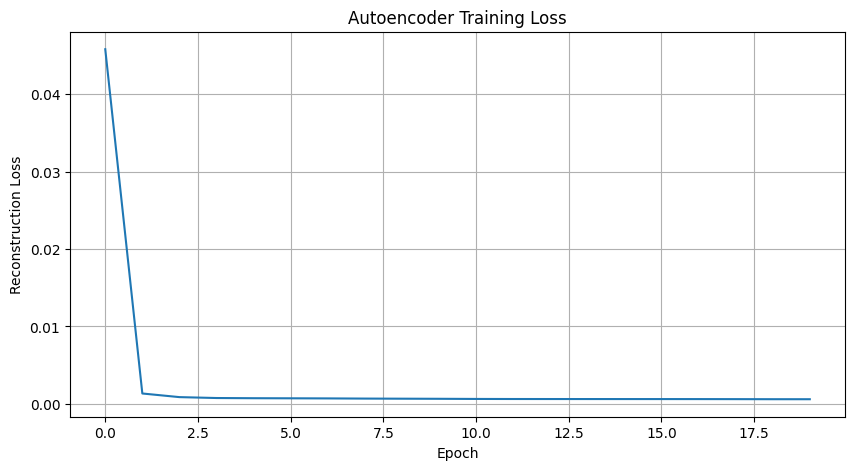

In [11]:
losses = train_autoencoder(model, train_loader, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE)

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Autoencoder Training Loss')
plt.grid(True)
plt.show()

## 4. Gaussian Mixture Model in Latent Space

Extract latent representations and fit GMM for anomaly detection.

In [12]:
def extract_latents(model, loader, return_labels=False):
    """Extract latent representations from data."""
    model.eval()
    all_latents = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting latents'):
            if isinstance(batch, (list, tuple)) and len(batch) == 2:
                x, labels = batch
                x = x.to(device)
                z = model.encode(x)
                all_latents.append(z.cpu())
                all_labels.append(labels)
            else:
                x = batch.to(device)
                z = model.encode(x)
                all_latents.append(z.cpu())
    
    latents = torch.cat(all_latents, dim=0).numpy()
    
    if return_labels and all_labels:
        labels = torch.cat(all_labels, dim=0).numpy()
        return latents, labels
    
    return latents

In [13]:
print('Extracting latents from training data...')
Z_train = extract_latents(model, train_loader)

print('Extracting latents from test data...')
Z_test, y_test = extract_latents(model, test_loader, return_labels=True)

print(f'Training latents shape: {Z_train.shape}')
print(f'Test latents shape: {Z_test.shape}')
print(f'Test labels shape: {y_test.shape}')

Extracting latents from training data...


Extracting latents: 100%|██████████| 200/200 [00:00<00:00, 249.88it/s]


Extracting latents from test data...


Extracting latents: 100%|██████████| 200/200 [00:01<00:00, 164.86it/s]

Training latents shape: (204800, 64)
Test latents shape: (204800, 64)
Test labels shape: (204800,)


In [14]:
def fit_and_score_gmm(Z_train, Z_test, y_test, k=5):
    """Fit GMM on training latents and score test latents."""
    print(f'\nFitting GMM with K={k}...')
    
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=SEED)
    gmm.fit(Z_train)
    
    # Anomaly score: negative log-likelihood
    start = datetime.datetime.now()
    scores = -gmm.score_samples(Z_test)
    end = datetime.datetime.now()
    t = (end - start).total_seconds()
    
    # Convert labels to binary (0=normal, 1=anomaly)
    # Assuming label 2 = normal, others = anomaly
    y_binary = (y_test != 2).astype(int)
    
    # Compute metrics
    roc_auc = roc_auc_score(y_binary, scores)
    pr_auc = average_precision_score(y_binary, scores)
    aic = gmm.aic(Z_test)
    bic = gmm.bic(Z_test)
    
    # PR@1% and PR@2%
    precision, recall, _ = precision_recall_curve(y_binary, scores)
    
    pr_at_1 = 0.0
    pr_at_2 = 0.0
    for p, r in zip(precision, recall):
        if r >= 0.01:
            pr_at_1 = p
        if r >= 0.02:
            pr_at_2 = p
    
    return {
        'roc_auc': float(roc_auc),
        'pr_auc': float(pr_auc),
        'aic': float(aic),
        'bic': float(bic),
        'pr_at_1': float(pr_at_1),
        'pr_at_2': float(pr_at_2),
        'gmm': gmm,
        'scores': scores,
        'y_binary': y_binary
    }

In [15]:
# Try different k values and pick best PR-AUC
print(f'\n=== Grid Search over k ===')

best_k = None
best_pr_auc = -1
all_results = {}

for k in GMM_K_LIST:
    print(f'\nTesting k={k}...')
    result = fit_and_score_gmm(Z_train, Z_test, y_test, k=k)
    all_results[k] = result
    
    if result['pr_auc'] > best_pr_auc:
        best_pr_auc = result['pr_auc']
        best_k = k
    
    print(f'  k={k:2d}: ROC-AUC={result["roc_auc"]:.4f}, PR-AUC={result["pr_auc"]:.4f}, AIC={result["aic"]:.2f}, BIC={result["bic"]:.2f}')

print(f'\n{"="*70}')
print(f'BEST K: {best_k} (PR-AUC={best_pr_auc:.4f})')
print(f'{"="*70}')

# Use best results
results = all_results[best_k]

print(f'\nRESULTS - BLR + GMM ({food_type}) with K={best_k}')
print(f'{"="*70}')
print(f'ROC-AUC:  {results["roc_auc"]:.4f}')
print(f'PR-AUC:   {results["pr_auc"]:.4f}')
print(f'PR@1%:    {results["pr_at_1"]:.4f}')
print(f'PR@2%:    {results["pr_at_2"]:.4f}')
print(f'AIC:      {results["aic"]:.2f}')
print(f'BIC:      {results["bic"]:.2f}')


=== Grid Search over k ===

Testing k=13...

Fitting GMM with K=13...
  k=13: ROC-AUC=0.9762, PR-AUC=0.8215, AIC=-99443625.75, BIC=-99158378.31

Testing k=12...

Fitting GMM with K=12...
  k=12: ROC-AUC=0.9742, PR-AUC=0.8003, AIC=-99718715.75, BIC=-99455411.21

Testing k=11...

Fitting GMM with K=11...
  k=11: ROC-AUC=0.9744, PR-AUC=0.8020, AIC=-99699730.75, BIC=-99458369.10

Testing k=25...

Fitting GMM with K=25...
  k=25: ROC-AUC=0.9803, PR-AUC=0.8299, AIC=-99852470.75, BIC=-99303908.54

Testing k=24...

Fitting GMM with K=24...
  k=24: ROC-AUC=0.9795, PR-AUC=0.8291, AIC=-99708898.25, BIC=-99182278.93

Testing k=23...

Fitting GMM with K=23...
  k=23: ROC-AUC=0.9794, PR-AUC=0.8313, AIC=-99857907.00, BIC=-99353230.58

Testing k=37...

Fitting GMM with K=37...
  k=37: ROC-AUC=0.9815, PR-AUC=0.8410, AIC=-99836103.25, BIC=-99024226.26

Testing k=36...

Fitting GMM with K=36...
  k=36: ROC-AUC=0.9828, PR-AUC=0.8381, AIC=-99912449.50, BIC=-99122515.41

Testing k=35...

Fitting GMM with K

KeyboardInterrupt: 

## 5. Inference and Evaluation

Compute anomaly scores using negative log-likelihood from GMM and evaluate performance.

In [ ]:
scores = results['scores']
labels = results['y_binary']
roc_auc = results['roc_auc']
pr_auc = results['pr_auc']

print(f'\nNormal pixels: {(labels == 0).sum()}')
print(f'Anomaly pixels: {(labels == 1).sum()}')


Normal pixels: 201601
Anomaly pixels: 3199


## 6. Visualization and Results Analysis

Comprehensive spatial and statistical visualizations of anomaly detection results.

/tmp/ipykernel_6525/1109030266.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


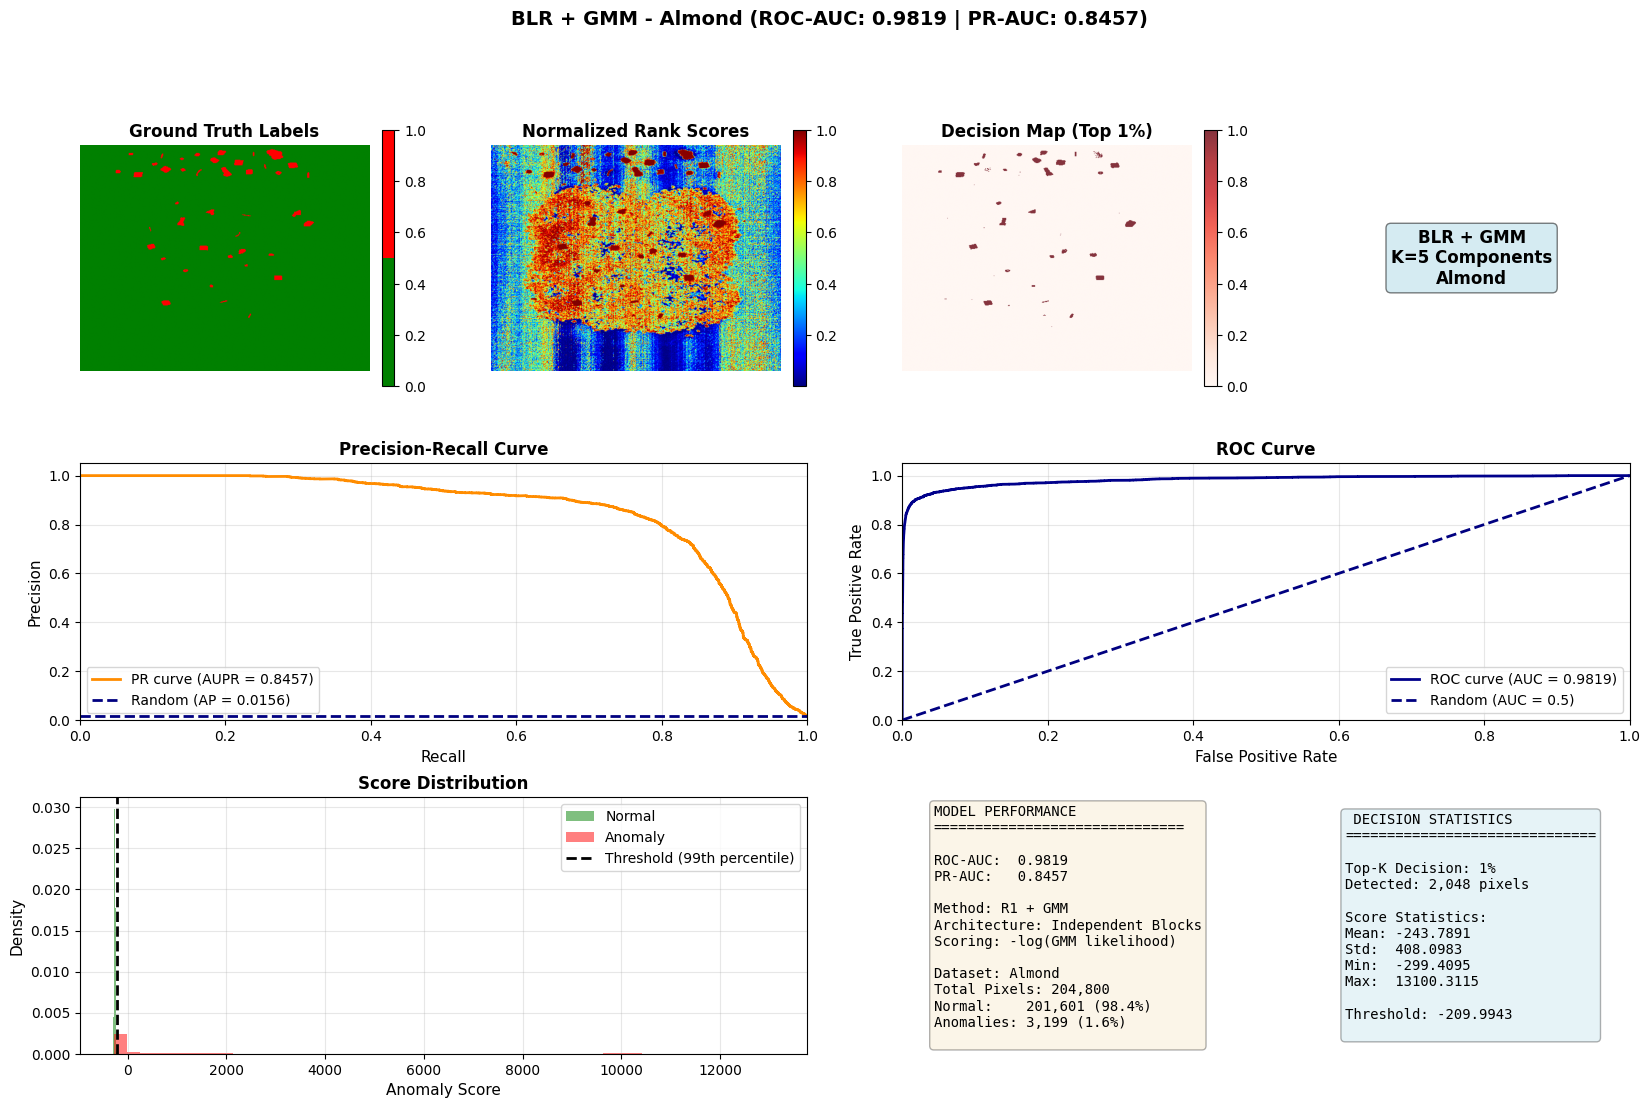


✅ Visualization complete!
   Top-K decision (1%): 2,048 pixels detected as anomalous


In [ ]:
from scipy.stats import rankdata
from matplotlib.colors import ListedColormap

# Compute normalized rank scores for visualization
rank_scores = rankdata(scores, method="average") / len(scores)
normalized_scores = rank_scores

# Compute decision threshold (top K%)
k_pixels = int(np.ceil(len(scores) * TOP_K_PERCENT / 100.0))
top_k_indices = np.argsort(-scores)[:k_pixels]
pixel_decision = np.zeros(len(scores), dtype=bool)
pixel_decision[top_k_indices] = True

# Reshape for spatial visualization
H, W = test_dataset.shape
score_map = scores.reshape(H, W)
normalized_score_map = normalized_scores.reshape(H, W)
label_map = labels.reshape(H, W)
decision_map = pixel_decision.reshape(H, W)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax2 = fig.add_subplot(gs[0, 0])
cmap_binary = ListedColormap(['green', 'red'])
im2 = ax2.imshow(label_map, cmap=cmap_binary)
ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 1])
im3 = ax3.imshow(normalized_score_map, cmap='jet')
ax3.set_title('Normalized Rank Scores', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 2])
im4 = ax4.imshow(decision_map, cmap='Reds', alpha=0.8)
ax4.set_title(f'Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

ax_info = fig.add_subplot(gs[0, 3])
ax_info.text(0.5, 0.5, f'BLR + GMM\n K = {best_k} Components\n{food_type}', 
             ha='center', va='center', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax_info.axis('off')

# Row 2: PR and ROC curves
ax5 = fig.add_subplot(gs[1, 0:2])
precision, recall, _ = precision_recall_curve(labels, scores)
ax5.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc:.4f})')
baseline = labels.sum() / len(labels)
ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('Recall', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2:4])
fpr, tpr, _ = roc_curve(labels, scores)
ax6.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate', fontsize=11)
ax6.set_ylabel('True Positive Rate', fontsize=11)
ax6.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.hist(scores[labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax7.hist(scores[labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax7.axvline(np.percentile(scores, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax7.set_xlabel('Anomaly Score', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""MODEL PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc:.4f}
PR-AUC:   {pr_auc:.4f}

Method: R1 + GMM
Architecture: Independent Blocks
Scoring: -log(GMM likelihood)

Dataset: {food_type}
Total Pixels: {len(scores):,}
Normal:    {(labels == 0).sum():,} ({100*(labels==0).sum()/len(labels):.1f}%)
Anomalies: {(labels == 1).sum():,} ({100*(labels==1).sum()/len(labels):.1f}%)
"""
ax8.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

ax9 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision.sum():,} pixels

Score Statistics:
Mean: {scores.mean():.4f}
Std:  {scores.std():.4f}
Min:  {scores.min():.4f}
Max:  {scores.max():.4f}

Threshold: {np.percentile(scores, 100 - TOP_K_PERCENT):.4f}
"""
ax9.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax9.axis('off')

plt.suptitle(f'BLR + GMM - {food_type} (ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete!")
print(f"   Top-K decision ({TOP_K_PERCENT}%): {pixel_decision.sum():,} pixels detected as anomalous")

In [ ]:
save_path = f'blr_gmm_{food_type.lower()}.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'gmm': results['gmm'],
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'config': {
        'input_dim': input_dim,
        'latent_dim': LATENT_DIM,
        'num_windows': NUM_WINDOWS,
        'gmm_k': best_k
    }
}, save_path)

print(f'Model saved to {save_path}')

# Save results to JSON
result_json = {
    'method': 'BLR + GMM',
    'food_type': food_type,
    'metrics': {
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'pr_at_1': results['pr_at_1'],
        'pr_at_2': results['pr_at_2']
    },
    'config': {
        'latent_dim': LATENT_DIM,
        'num_windows': NUM_WINDOWS,
        'gmm_k': best_k
    }
}

json_path = f'blr_gmm_{food_type.lower()}.json'
with open(json_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f'Results saved to {json_path}')

Model saved to blr_gmm_almond.pth
Results saved to blr_gmm_almond.json


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Generating UMAP visualization of test features...


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fit complete. Shape: (204800, 2)


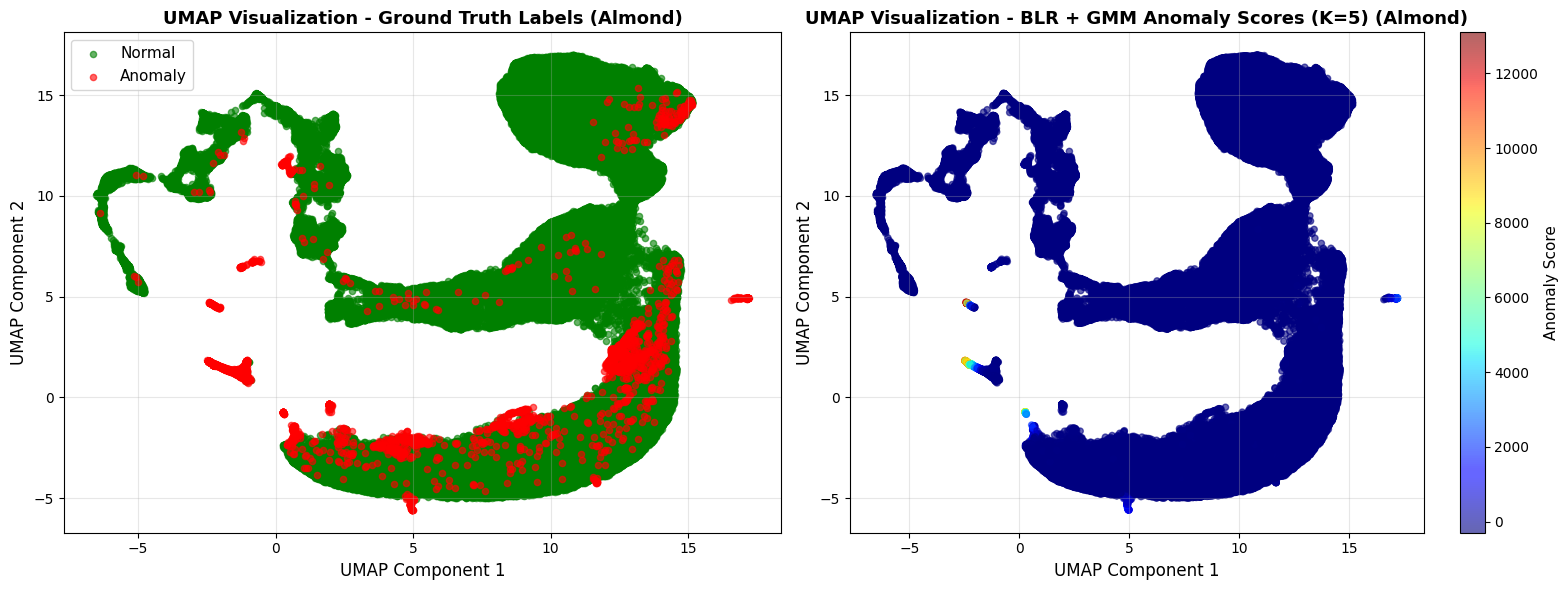


✅ UMAP visualization complete!
   Normal points (green): 201,601
   Anomaly points (red): 3,199


In [ ]:
# UMAP Visualization of Test Features with Labels
from umap import UMAP

print('\nGenerating UMAP visualization of test features...')

# Fit UMAP on test latents
umap_reducer = UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
Z_test_umap = umap_reducer.fit_transform(Z_test)

print(f'UMAP fit complete. Shape: {Z_test_umap.shape}')

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: UMAP colored by ground truth label
ax1 = axes[0]
scatter1 = ax1.scatter(Z_test_umap[labels == 0, 0], 
                       Z_test_umap[labels == 0, 1],
                       c='green', label='Normal', alpha=0.6, s=20)
scatter2 = ax1.scatter(Z_test_umap[labels == 1, 0], 
                       Z_test_umap[labels == 1, 1],
                       c='red', label='Anomaly', alpha=0.6, s=20)
ax1.set_xlabel('UMAP Component 1', fontsize=12)
ax1.set_ylabel('UMAP Component 2', fontsize=12)
ax1.set_title(f'UMAP Visualization - Ground Truth Labels ({food_type})', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: UMAP colored by GMM anomaly score
ax2 = axes[1]
scatter3 = ax2.scatter(Z_test_umap[:, 0], Z_test_umap[:, 1],
                       c=scores, cmap='jet', alpha=0.6, s=20)
ax2.set_xlabel('UMAP Component 1', fontsize=12)
ax2.set_ylabel('UMAP Component 2', fontsize=12)
ax2.set_title(f'UMAP Visualization - BLR + GMM Anomaly Scores ({food_type})', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter3, ax=ax2)
cbar.set_label('Anomaly Score', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n✅ UMAP visualization complete!')
print(f'   Normal points (green): {(labels == 0).sum():,}')
print(f'   Anomaly points (red): {(labels == 1).sum():,}')